# P1 · 01 — Decomposition & stationarity: the diagnosis before the model

Two foundational ideas:

1. **Decomposition** — split a series into **trend + seasonal + remainder** so we
   can *see* the structure we need to model.
2. **Stationarity** — a series whose statistical properties (mean, variance,
   autocorrelation) don't change over time. ARIMA assumes it; this notebook shows
   how to **test** for it and how much **differencing** is needed to get there.

We'll finish by reading the **ACF/PACF** plots — the classical "fingerprint" that
suggests ARIMA orders.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

q = data.load_quarterly()
nsa = q["gdp_nsa"]
# statsmodels wants a real datetime index for decomposition plots:
nsa_ts = nsa.copy(); nsa_ts.index = nsa.index.to_timestamp(how="start")
nsa_ts.tail()

quarter
2025-01-01    81395975.0
2025-04-01    75355723.5
2025-07-01    75344227.1
2025-10-01    84649351.7
2026-01-01    87771040.1
Freq: QS-OCT, Name: gdp_nsa, dtype: float64

### Additive vs multiplicative decomposition

* **Additive:** $y_t = T_t + S_t + R_t$ — use when the seasonal swing is a roughly
  *constant size* regardless of level.
* **Multiplicative:** $y_t = T_t \times S_t \times R_t$ — use when the seasonal
  swing *grows with the level* (bigger economy → bigger absolute seasonal gap).

GDP grows exponentially and its seasonal swing grows with it → **multiplicative**
(equivalently: *additive on the log*). Let's decompose with period = 4 quarters.

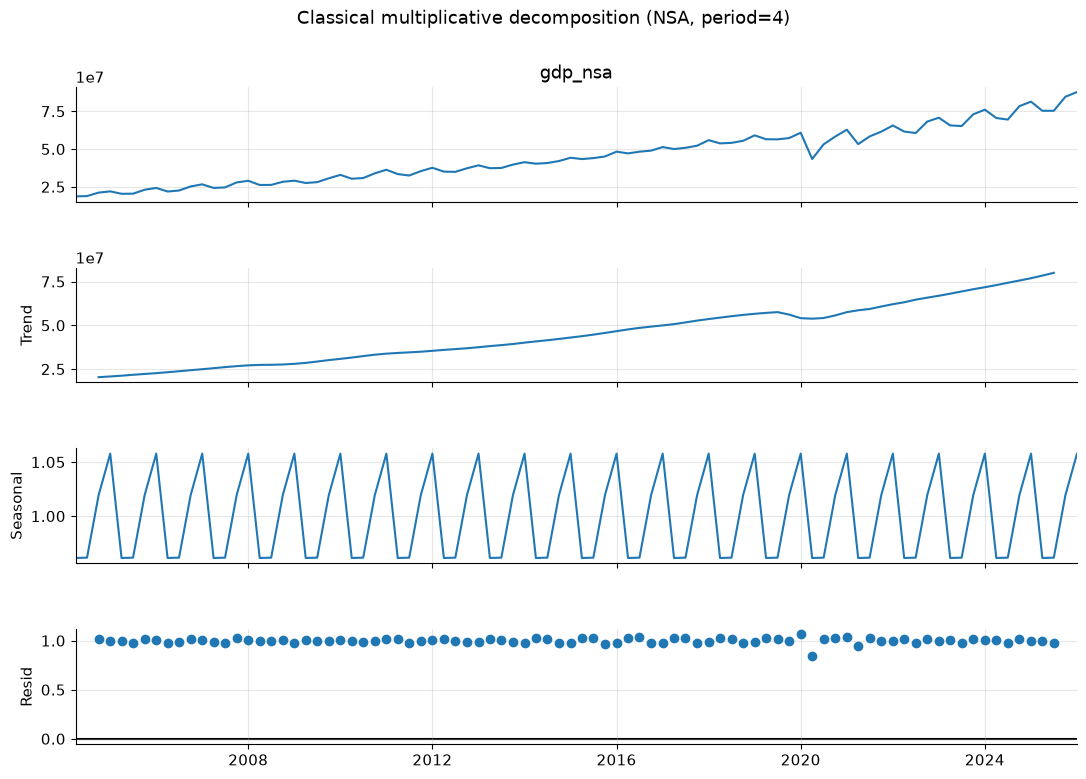

Seasonal factors by calendar quarter (1.0 = on-trend):
quarter
1    1.058
2    0.961
3    0.962
4    1.019
Name: seasonal, dtype: float64


In [2]:
dec = seasonal_decompose(nsa_ts, model="multiplicative", period=4)
fig = dec.plot(); fig.set_size_inches(11, 8)
fig.suptitle("Classical multiplicative decomposition (NSA, period=4)", y=1.01)
plt.show()

# The seasonal factors: how much each quarter sits above/below trend.
seasonal_factors = dec.seasonal.groupby(dec.seasonal.index.quarter).mean()
print("Seasonal factors by calendar quarter (1.0 = on-trend):")
print((seasonal_factors).round(3))

Read the factors: a value of **1.05** means that quarter runs ~5% **above** the
local trend; **0.96** means ~4% below. You should see Q1 (Jan–Mar) well above 1
and Q2 (Apr–Jun) below — India's fiscal year-end quarter is the strongest.

Classical `seasonal_decompose` uses simple moving averages and assumes a *fixed*
seasonal shape. **STL** (Seasonal-Trend decomposition using Loess) is more robust
and lets the seasonal shape evolve slowly. We run STL on the **log** (so the
multiplicative structure becomes additive).

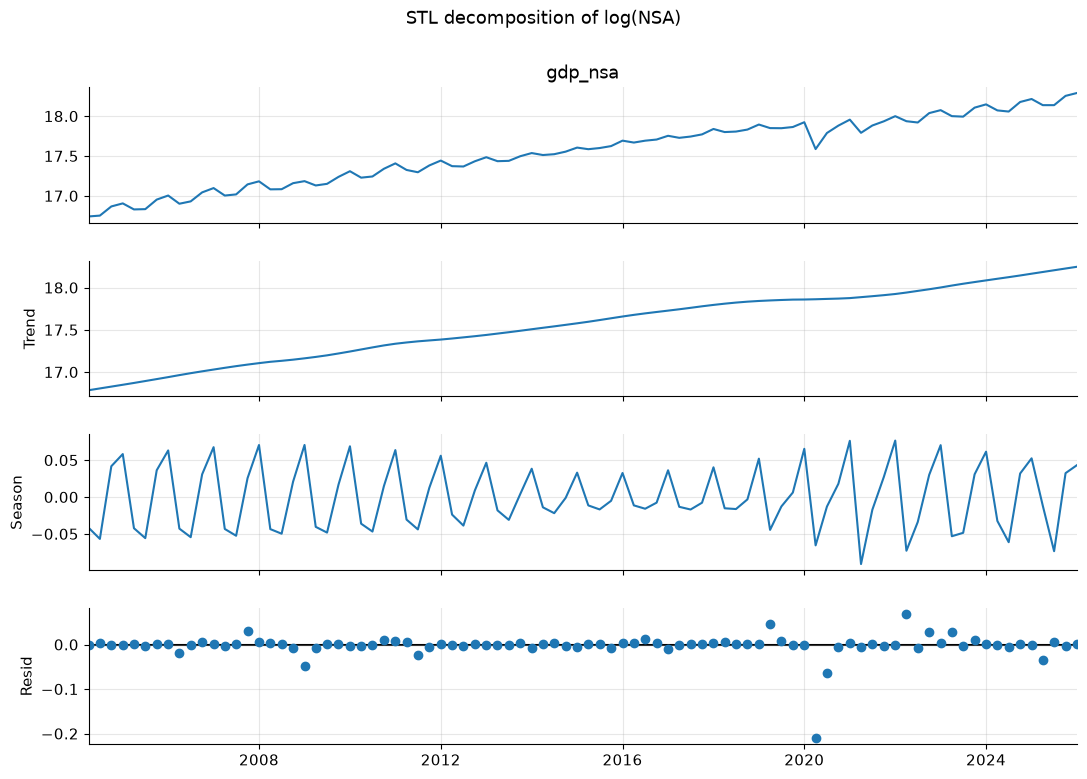

Seasonal strength Fs = 0.74  (0 = none, 1 = very strong)


In [3]:
stl = STL(np.log(nsa_ts), period=4, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 8)
fig.suptitle("STL decomposition of log(NSA)", y=1.01)
plt.show()

# Strength of seasonality (Hyndman): 1 - Var(remainder)/Var(seasonal+remainder)
res, seas = stl.resid, stl.seasonal
Fs = max(0.0, 1 - res.var() / (seas + res).var())
print(f"Seasonal strength Fs = {Fs:.2f}  (0 = none, 1 = very strong)")

A seasonal strength above ~0.6 means seasonality is a *dominant* feature — we'll
definitely want a **seasonal** model (SARIMA / Holt-Winters), not a plain one.

### Stationarity: test, don't eyeball

A stationary series has a stable mean and variance. ARIMA models the *stationary*
version of a series, so we must figure out how many times to difference. We use
**two complementary tests** because each has a different null hypothesis:

| test | null hypothesis $H_0$ | reject (p<0.05) means |
|------|----------------------|------------------------|
| **ADF** (Augmented Dickey-Fuller) | has a unit root (non-stationary) | *stationary* |
| **KPSS** | is stationary | *non-stationary* |

The trustworthy conclusion is when they **agree**. ADF wanting stationary *and*
KPSS not-rejecting stationary = confident green light.

In [4]:
def stat_tests(s, name):
    s = pd.Series(s).dropna()
    adf_p = adfuller(s, autolag="AIC")[1]
    kpss_p = kpss(s, regression="c", nlags="auto")[1]
    return {
        "series": name,
        "ADF p": round(adf_p, 3),
        "KPSS p": round(kpss_p, 3),
        "ADF → ": "stationary" if adf_p < 0.05 else "unit root",
        "KPSS → ": "stationary" if kpss_p > 0.05 else "non-stationary",
    }

logn = np.log(nsa)
pd.DataFrame([
    stat_tests(nsa,                       "level"),
    stat_tests(logn,                      "log level"),
    stat_tests(logn.diff(),               "log · 1st diff"),
    stat_tests(logn.diff().diff(4),       "log · 1st + seasonal(4) diff"),
])

,series,ADF p,KPSS p,ADF →,KPSS →
0,level,0.999,0.01,unit root,non-stationary
1,log level,0.752,0.01,unit root,non-stationary
2,log · 1st diff,0.000,0.10,stationary,stationary
3,log · 1st + seasonal(4) diff,0.000,0.10,stationary,stationary


Typical reading for this series:
* **level / log level** → ADF says unit root, KPSS says non-stationary → *not* stationary.
* **1st diff of log** → removes the trend; closer to stationary but seasonality
  may still trip KPSS.
* **1st + seasonal diff** → both tests agree it's stationary.

That tells us the differencing orders for SARIMA: regular **d = 1**, seasonal
**D = 1**, season **m = 4**. (We'll let the model confirm in notebook 04.)

### ACF & PACF — the order-selection fingerprint

On the *stationary* (differenced) series:
* **ACF** (autocorrelation) cutting off after lag *q* → suggests an **MA(q)** term.
* **PACF** (partial autocorrelation) cutting off after lag *p* → suggests an **AR(p)** term.
* Spikes at lag 4, 8, … → the **seasonal** AR/MA terms.

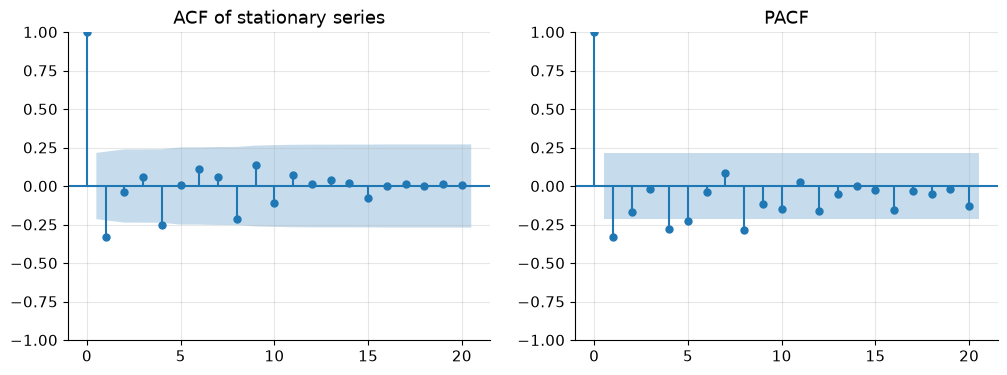

In [5]:
stat = np.log(nsa).diff().diff(4).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(stat, lags=20, ax=axes[0]);  axes[0].set_title("ACF of stationary series")
plot_pacf(stat, lags=20, ax=axes[1], method="ywm"); axes[1].set_title("PACF")
plt.show()

Bars outside the shaded band are statistically significant. Don't agonise over a
perfect read — in practice we use ACF/PACF to pick a *short list* of candidate
orders, then let an information criterion (AIC) choose between them (notebook 04).

---
**Next (02):** before any fancy model, build the **evaluation harness** — baselines,
metrics, and rolling-origin backtesting — so every later model is judged honestly.